In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [3]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

In [4]:
from DataLoader import Dataloader
from Engine import Engine

In [5]:
data_path = Path(r"D:\All Python\Kaggle\data\titanic\train.csv")
# data_path_heart = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'
dataloader = Dataloader(data_path=data_path, seed=42)

In [6]:
dataloader.data

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_0,Embarked_1,Embarked_2
PassengerId,,,,,,,,,,
1,0,3,0,22.0,1,0,7.2500,1,0,0
2,1,1,1,38.0,1,0,71.2833,0,1,0
3,1,3,1,26.0,0,0,7.9250,1,0,0
4,1,1,1,35.0,1,0,53.1000,1,0,0
5,0,3,0,35.0,0,0,8.0500,1,0,0
...,...,...,...,...,...,...,...,...,...,...
887,0,2,0,27.0,0,0,13.0000,1,0,0
888,1,1,1,19.0,0,0,30.0000,1,0,0
889,0,3,1,39.0,1,2,23.4500,1,0,0


In [7]:
model = Engine(data=dataloader.data)
model.fit()

Accuracy for Train is 0.8282504012841091
Accuracy for Test is 0.8022388059701493


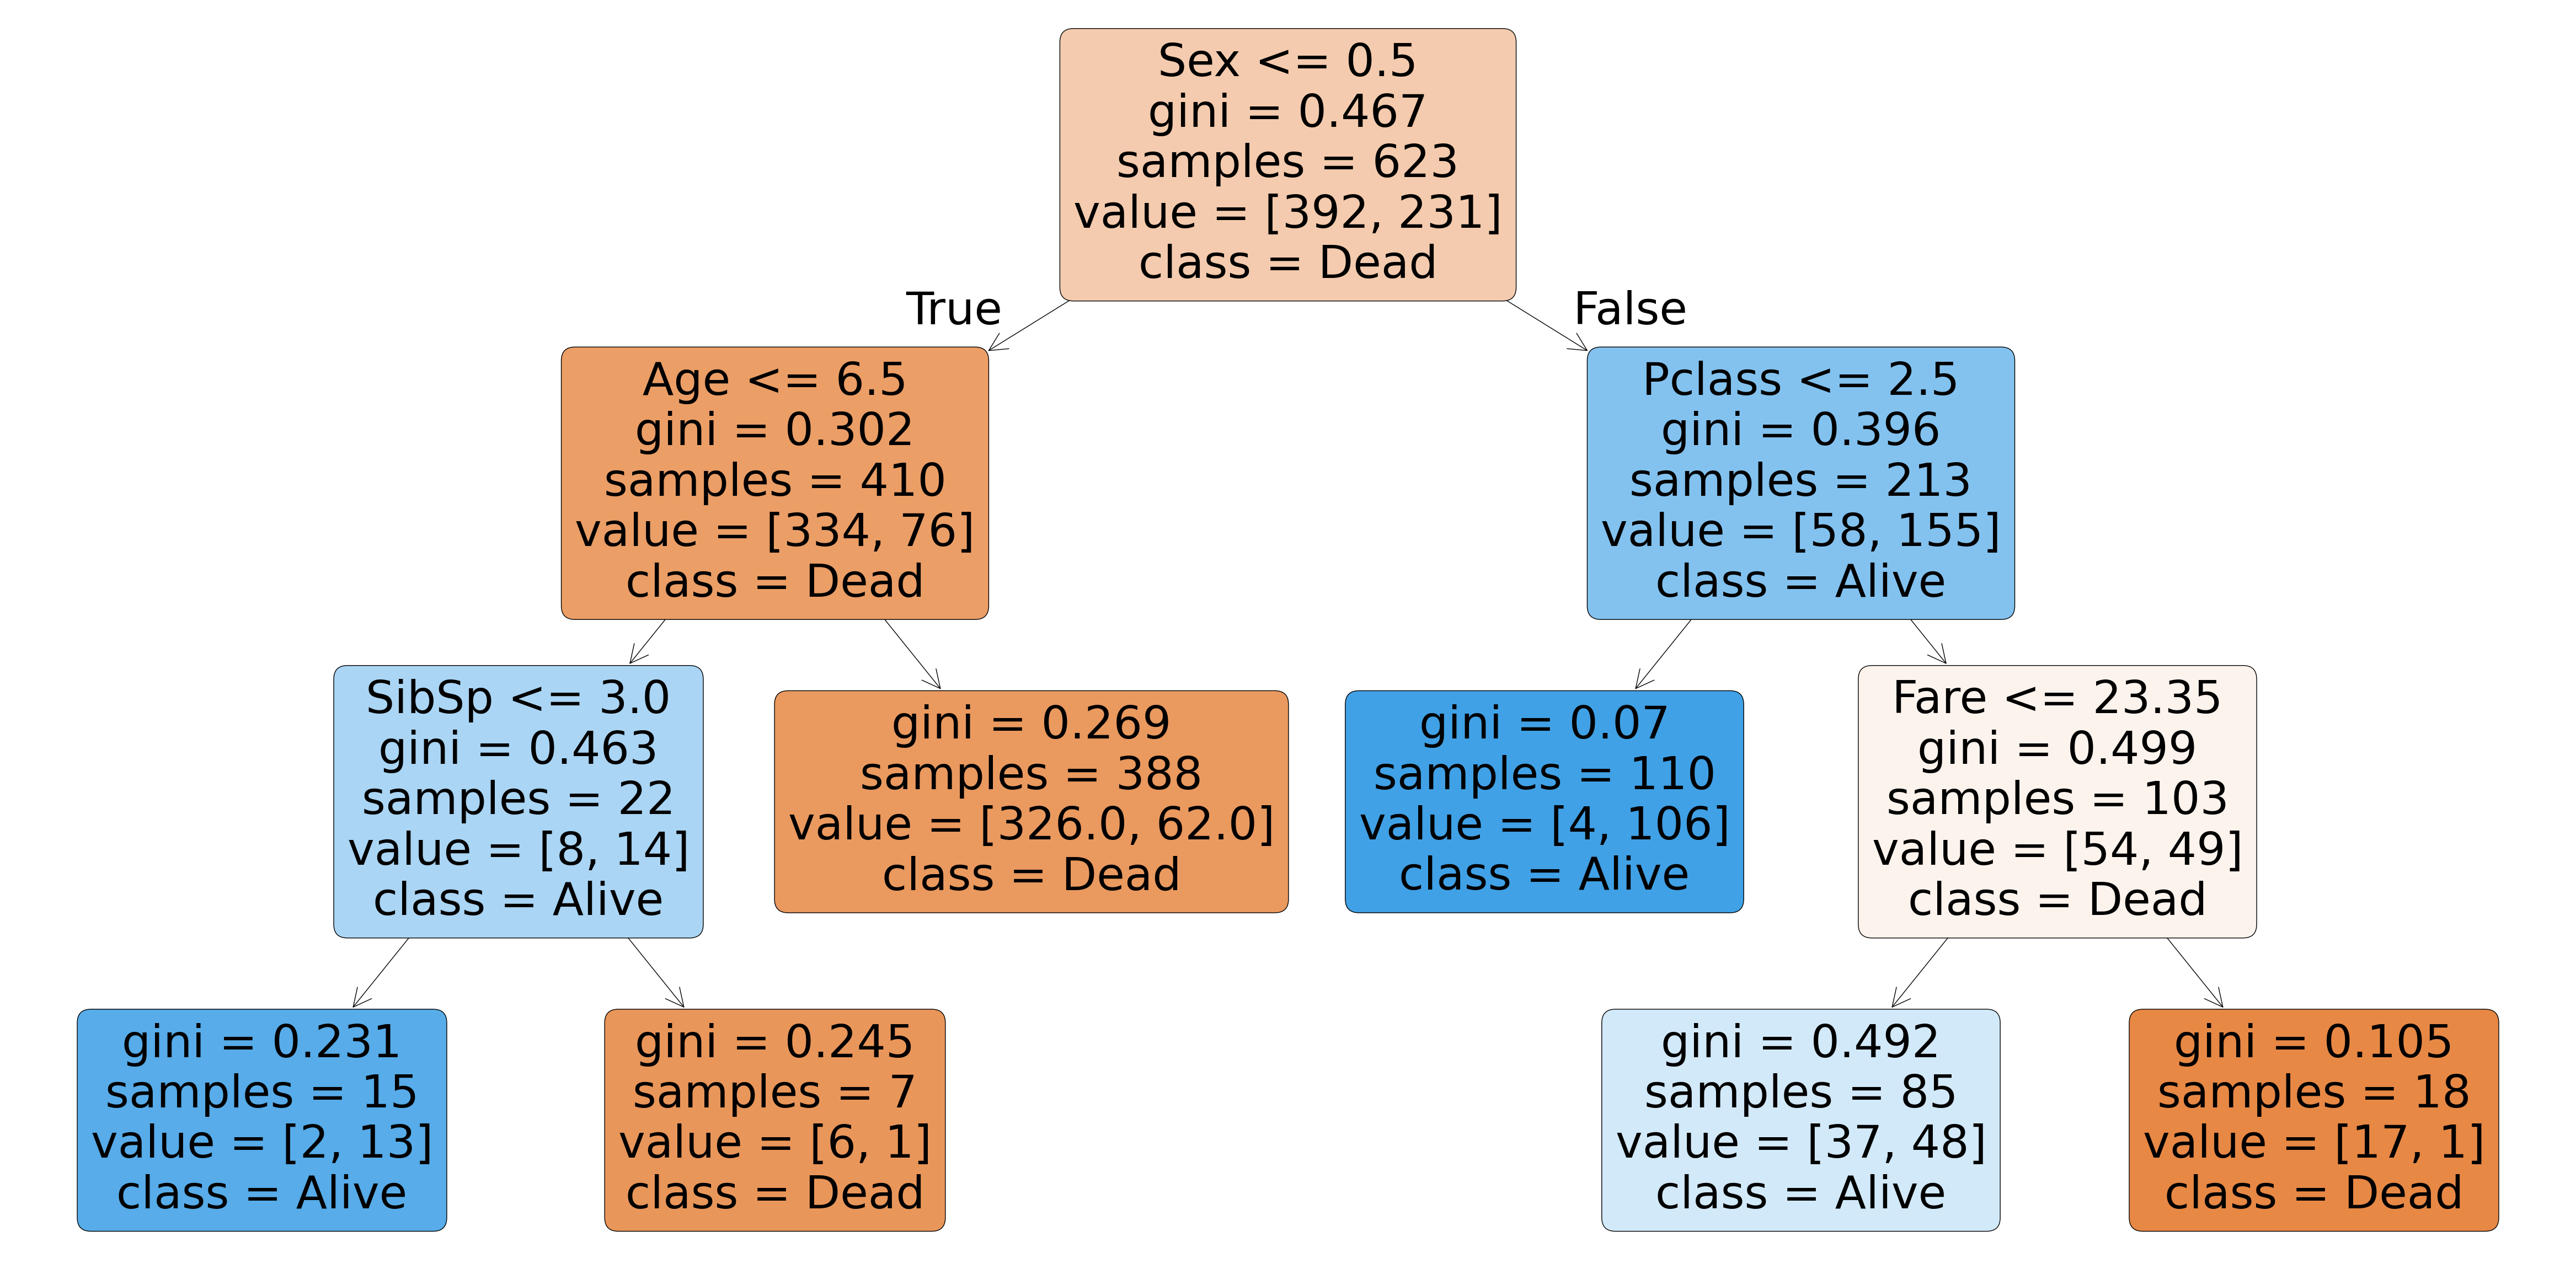

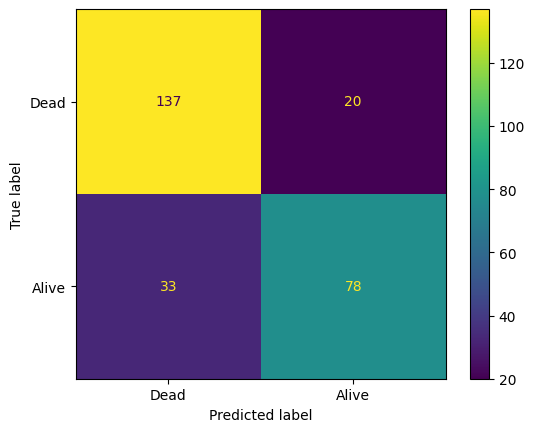

In [14]:
model.pre_tree(if_plot_tree=True, if_confusion_matrix=True, alpha=0.008)

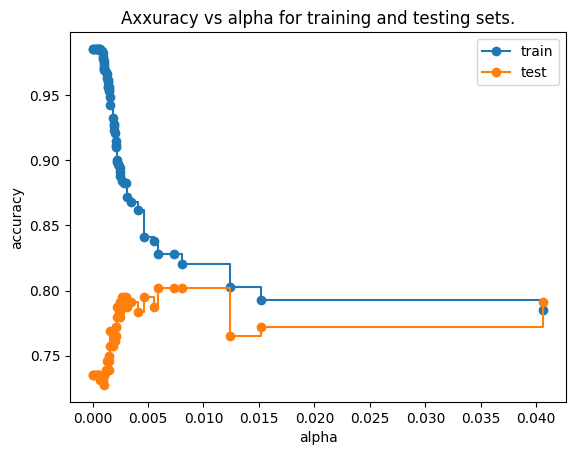

In [10]:
model.find_alpha_for_pruning(plot_loss=True)

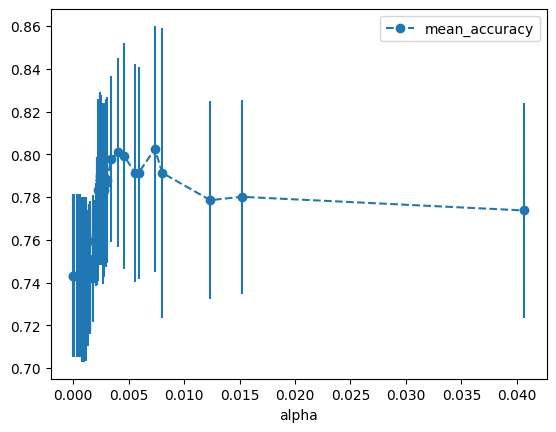

In [11]:
model.cross_validation_to_find_best_alpha()

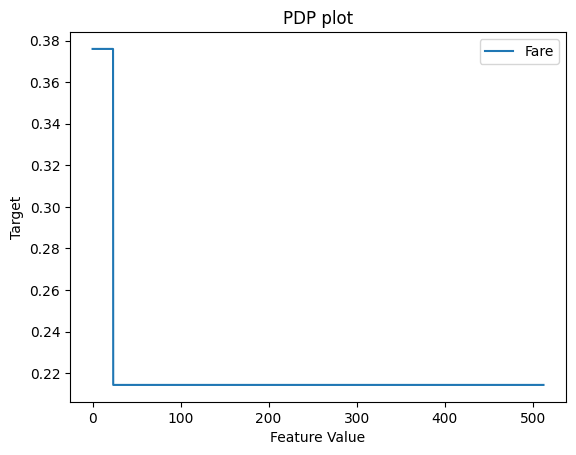

In [30]:
features1 = {"Pclass":[1, 2, 3]}
features2 = {"Age": sorted(list(model.data["Age"].unique()))}
features3 = {"Sex": [0, 1]}
features4 = {"SibSp":[0, 1, 2, 3, 4, 5, 6, 7, 8]}
features5 = {"Fare": sorted(list(model.data["Fare"].unique()))}

model.partial_dependence_plot(features=features5)

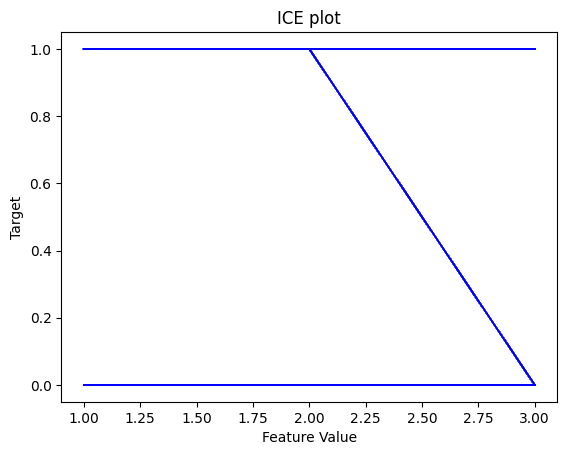

In [15]:
model.individual_conditional_expectation(features=features1)

[INFO] Empty Interval 341.5528 to 426.941


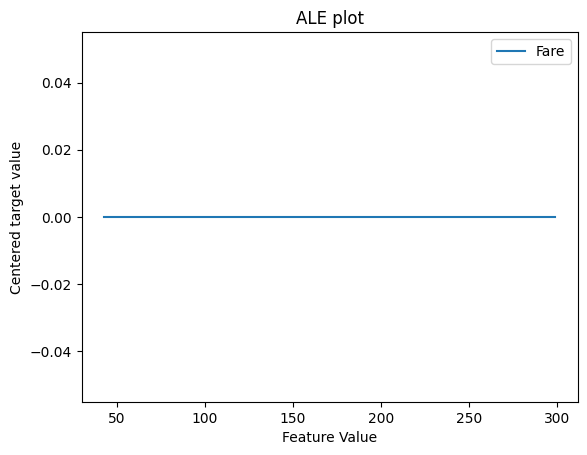

In [29]:
features = ["Pclass", "Age", "Sex", "SibSp", "Fare"]
model.accumulated_local_effects_plot(features=[features[4]], n=6)